# Chapter 142 — Coordinate Systems

> **Prerequisites:** ch141 (Linear Independence), ch139 (Basis and Dimension), ch135 (Orthogonality), ch124 (Vector Representation)  
> **You will learn:**
> - How a basis defines a coordinate system and why coordinates depend on the chosen basis
> - How to convert vectors between different coordinate systems
> - Orthonormal, oblique, and polar coordinate systems — and when each is useful
> - How change of basis is used in signal processing, graphics, and ML
> - The computational cost and numerical stability trade-offs of coordinate choices
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **coordinate system** is a way to assign a unique label (a tuple of numbers) to every point in a space. Every coordinate system for a vector space V is defined by a basis B = {**b₁**, ..., **bₙ**}: the coordinates of a vector **v** are the scalars (c₁, ..., cₙ) such that **v** = c₁**b₁** + ... + cₙ**bₙ**.

The same physical vector has different coordinates in different coordinate systems — but the vector itself is unchanged. Coordinate systems are bookkeeping, not substance.

**Why coordinate systems matter:**
- Computation happens in coordinates. Choosing the right coordinate system makes computations simpler, faster, or more numerically stable.
- In graphics and robotics, different objects (camera, world, robot arm) have their own coordinate frames, and transforming between them is a fundamental operation.
- In ML, feature spaces are coordinate systems. PCA finds a new coordinate system where variance is maximized along axes — the same data, re-expressed.

**Common misconception:** "The standard (Cartesian) coordinate system is special." For computation, it is merely convenient. Many problems are simpler in non-standard coordinates: Fourier analysis works in a frequency coordinate system; PCA works in a variance-aligned coordinate system.

---

## 2. Intuition & Mental Models

**Geometric model:** Think of a coordinate system as a grid drawn on space. The standard grid has perpendicular lines spaced 1 unit apart. A non-standard basis draws a different grid — perhaps slanted, perhaps with different spacing. Any point lies at a unique grid intersection, but the grid address changes when the grid changes.

**Computational model:** Think of coordinates as the output of a measurement device. Each basis vector is one sensor. The sensor reads how much of the signal is aligned with its direction. Change the sensors, and the readings change — even though the signal (the vector) is the same.

Recall from ch139 (Basis and Dimension): every basis provides unique coordinates. Recall from ch141 (Linear Independence): independence is what makes coordinates unique — dependent bases give ambiguous readings.

**Physical analogy:** GPS coordinates and city addresses both locate the same place, but in different coordinate systems. Converting between them requires knowing the relationship between the two systems — this is the change-of-basis matrix.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_8228\3522969263.py:55: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8228\3522969263.py:55: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


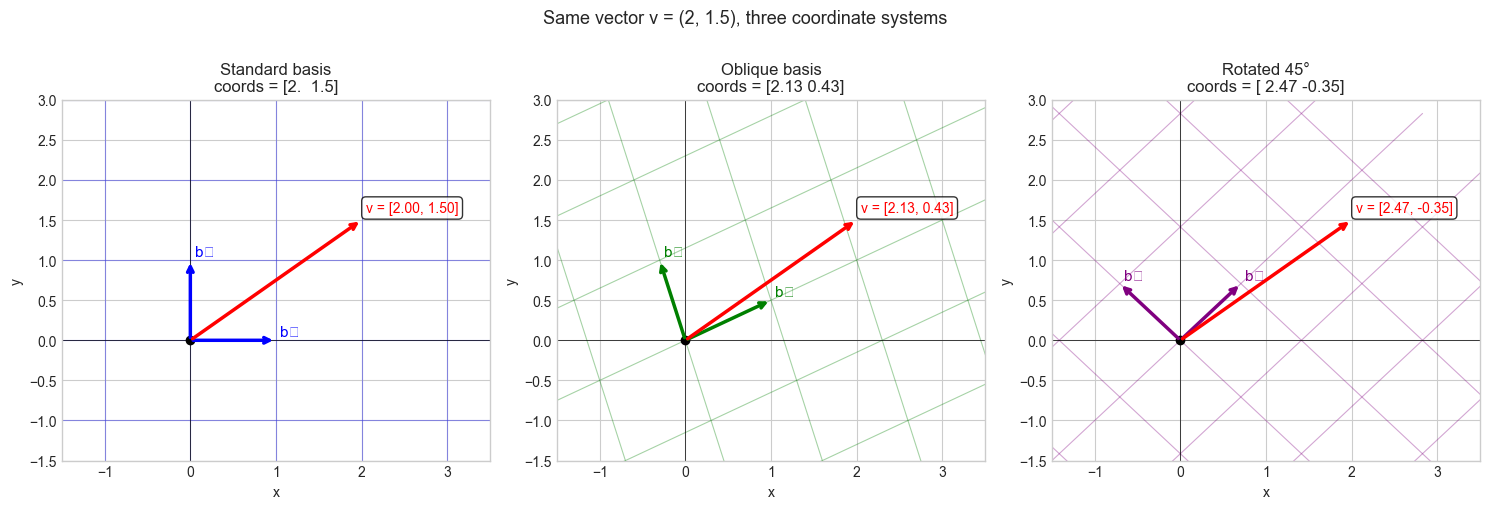

In [1]:
# --- Visualization: Same vector in three different coordinate systems ---

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

v = np.array([2.0, 1.5])  # the actual vector — same in all panels

def draw_grid(ax, b1, b2, color, alpha=0.35):
    """Draw the grid lines for a basis (b1, b2)."""
    t = np.linspace(-4, 4, 100)
    for i in np.arange(-3, 4):
        # Lines parallel to b1 at offset i*b2
        pts = np.outer(t, b1) + i * b2
        ax.plot(pts[:,0], pts[:,1], color=color, lw=0.8, alpha=alpha)
        # Lines parallel to b2 at offset i*b1
        pts = np.outer(t, b2) + i * b1
        ax.plot(pts[:,0], pts[:,1], color=color, lw=0.8, alpha=alpha)

bases = [
    (np.array([1.,0.]), np.array([0.,1.]),   'Standard basis', 'blue'),
    (np.array([1.,0.5]), np.array([-0.3,1.]), 'Oblique basis',  'green'),
    (np.array([1.,1.])/np.sqrt(2), np.array([-1.,1.])/np.sqrt(2), 'Rotated 45°', 'purple'),
]

for ax, (b1, b2, title, color) in zip(axes, bases):
    draw_grid(ax, b1, b2, color)
    # Basis vectors
    ax.annotate('', xy=b1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.annotate('', xy=b2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color=color, lw=2.5))

    # The vector v
    ax.annotate('', xy=v, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2.5))

    # Compute coordinates
    B = np.column_stack([b1, b2])
    coords = np.linalg.solve(B, v)

    ax.text(v[0]+0.05, v[1]+0.1, f'v = [{coords[0]:.2f}, {coords[1]:.2f}]',
             fontsize=10, color='red',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.text(b1[0]+0.05, b1[1]+0.05, 'b₁', fontsize=11, color=color)
    ax.text(b2[0]+0.05, b2[1]+0.05, 'b₂', fontsize=11, color=color)

    ax.set_xlim(-1.5, 3.5); ax.set_ylim(-1.5, 3)
    ax.set_title(f'{title}\ncoords = {coords.round(2)}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.plot(0, 0, 'ko', markersize=6)

plt.suptitle('Same vector v = (2, 1.5), three coordinate systems', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

Let B = {**b₁**, ..., **bₙ**} be a basis for V. The **coordinate vector** of **v** in basis B is:
```
[v]_B = (c₁, ..., cₙ)  where  v = c₁b₁ + ... + cₙbₙ
```

This is found by solving the linear system:
```
B · [v]_B = v    where B = [b₁ | b₂ | ... | bₙ]
```

**Orthonormal basis (special case):** If the basis is orthonormal (**bᵢ** · **bⱼ** = δᵢⱼ), then:
```
cᵢ = bᵢ · v    (projection formula — no matrix inversion needed)
[v]_B = Bᵀ v
```
This is why orthonormal bases are computationally preferred — coordinates are just dot products. *(The projection formula was introduced in ch134.)*

**Change of basis:** Given two bases B₁ and B₂:
```
[v]_B2 = P · [v]_B1

where P = B₂⁻¹ · B₁
```
P is the **change-of-basis matrix** from B₁ to B₂.

**Key types of coordinate systems:**

| Type | Basis condition | Coordinate formula | Cost |
|------|----------------|-------------------|------|
| Orthonormal | ‖**bᵢ**‖=1, **bᵢ**·**bⱼ**=0 | cᵢ = **bᵢ**·**v** | O(n) per coord |
| Orthogonal | **bᵢ**·**bⱼ**=0 | cᵢ = (**bᵢ**·**v**)/‖**bᵢ**‖² | O(n) per coord |
| General (oblique) | Independent | solve B**c**=**v** | O(n²) or O(n³) |

Orthonormal bases cost least. General bases cost most. This is why Gram-Schmidt (ch135) and QR decomposition matter.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Coordinate system class ---

import numpy as np


class CoordinateSystem:
    """
    A coordinate system defined by a basis matrix.

    The basis matrix B has basis vectors as columns.
    Given vector v in standard coordinates, coordinates in this system
    are found by solving B @ c = v.
    """

    def __init__(self, basis_vectors):
        """
        Args:
            basis_vectors: list of np.ndarray or np.ndarray shape (n, k)
        """
        if isinstance(basis_vectors, list):
            self.B = np.column_stack(basis_vectors).astype(float)
        else:
            self.B = basis_vectors.astype(float)

        self.n, self.k = self.B.shape
        self._is_orthonormal = self._check_orthonormal()

    def _check_orthonormal(self, tol=1e-9):
        """Check if basis is orthonormal (Bᵀ B = I)."""
        G = self.B.T @ self.B
        return np.allclose(G, np.eye(self.k), atol=tol)

    def to_coords(self, v):
        """
        Convert standard-basis vector v to coordinates in this system.

        Args:
            v: np.ndarray, shape (n,)

        Returns:
            np.ndarray of coordinates, shape (k,)
        """
        if self._is_orthonormal:
            # Fast path: just dot products
            return self.B.T @ v
        else:
            # General: solve linear system
            c, _, _, _ = np.linalg.lstsq(self.B, v, rcond=None)
            return c

    def to_standard(self, c):
        """
        Convert coordinates in this system back to standard-basis vector.

        Args:
            c: np.ndarray of coordinates, shape (k,)

        Returns:
            np.ndarray, shape (n,)
        """
        return self.B @ c

    def change_to(self, other, c):
        """
        Convert coordinates c (in self) to coordinates in other system.

        Args:
            other: CoordinateSystem
            c: np.ndarray of coordinates in self, shape (k,)

        Returns:
            np.ndarray of coordinates in other, shape (other.k,)
        """
        v_standard = self.to_standard(c)
        return other.to_coords(v_standard)

    def __repr__(self):
        return (f"CoordinateSystem(dim={self.n}, k={self.k}, "
                f"orthonormal={self._is_orthonormal})")


# --- Usage examples ---
# Standard coordinate system
cs_std = CoordinateSystem(np.eye(3))

# Rotated coordinate system (45° rotation in xy-plane)
theta = np.pi / 4
b1 = np.array([np.cos(theta), np.sin(theta), 0.])
b2 = np.array([-np.sin(theta), np.cos(theta), 0.])
b3 = np.array([0., 0., 1.])
cs_rot = CoordinateSystem([b1, b2, b3])

# Oblique coordinate system (non-orthogonal)
cs_obl = CoordinateSystem([np.array([1.,0.5,0.]), np.array([0.,1.,0.3]), np.array([0.,0.,1.])])

v = np.array([1.0, 0.0, 0.0])  # the x-axis unit vector

print(f"Vector v = {v}")
print()
print(f"Standard coords: {cs_std.to_coords(v).round(4)}")
print(f"Rotated coords:  {cs_rot.to_coords(v).round(4)}  (orthonormal: {cs_rot._is_orthonormal})")
print(f"Oblique coords:  {cs_obl.to_coords(v).round(4)}  (orthonormal: {cs_obl._is_orthonormal})")

# Round-trip test
c_rot = cs_rot.to_coords(v)
v_back = cs_rot.to_standard(c_rot)
print(f"\nRound-trip (rotated): {v_back.round(10)}  (matches: {np.allclose(v, v_back)})")

# Convert between non-standard systems
c_rot_to_obl = cs_rot.change_to(cs_obl, c_rot)
print(f"\nRotated coords -> Oblique coords: {c_rot_to_obl.round(4)}")
v_check = cs_obl.to_standard(c_rot_to_obl)
print(f"Back to standard:                 {v_check.round(10)}  (matches v: {np.allclose(v, v_check)})")

Vector v = [1. 0. 0.]

Standard coords: [1. 0. 0.]
Rotated coords:  [ 0.7071 -0.7071  0.    ]  (orthonormal: True)
Oblique coords:  [ 1.   -0.5   0.15]  (orthonormal: False)

Round-trip (rotated): [ 1. -0.  0.]  (matches: True)

Rotated coords -> Oblique coords: [ 1.   -0.5   0.15]
Back to standard:                 [ 1. -0.  0.]  (matches v: True)


---

## 6. Experiments

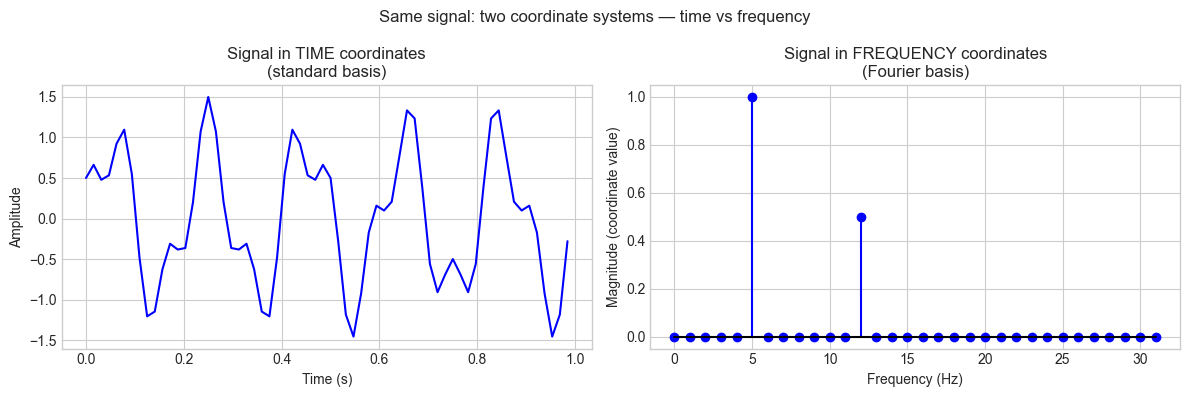

Dominant frequency coordinates:
  freq=5.0 Hz, magnitude=1.000
  freq=12.0 Hz, magnitude=0.500
  freq=25.0 Hz, magnitude=0.000


In [3]:
# --- Experiment 1: Fourier basis as a coordinate system ---
# The Fourier transform is a change of coordinates from time to frequency.
# In the Fourier basis, a signal's coordinates are its frequency components.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

N = 64  # signal length  <-- modify
t = np.linspace(0, 1, N, endpoint=False)

# Signal: sum of two sinusoids
FREQ1 = 5   # Hz  <-- modify
FREQ2 = 12  # Hz  <-- modify
signal = np.sin(2 * np.pi * FREQ1 * t) + 0.5 * np.cos(2 * np.pi * FREQ2 * t)

# Fourier "coordinates" — how much of each frequency is present
fft_coords = np.fft.fft(signal) / N  # normalized
freqs = np.fft.fftfreq(N, d=1/N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t, signal, 'b-', lw=1.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Signal in TIME coordinates\n(standard basis)')

pos_freqs = freqs[:N//2]
magnitudes = np.abs(fft_coords[:N//2]) * 2
ax2.stem(pos_freqs, magnitudes, markerfmt='bo', linefmt='b-', basefmt='k-')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude (coordinate value)')
ax2.set_title('Signal in FREQUENCY coordinates\n(Fourier basis)')

plt.suptitle('Same signal: two coordinate systems — time vs frequency', fontsize=12)
plt.tight_layout()
plt.show()

# Identify dominant frequencies
top_idx = np.argsort(magnitudes)[-3:][::-1]
print("Dominant frequency coordinates:")
for i in top_idx:
    print(f"  freq={pos_freqs[i]:.1f} Hz, magnitude={magnitudes[i]:.3f}")

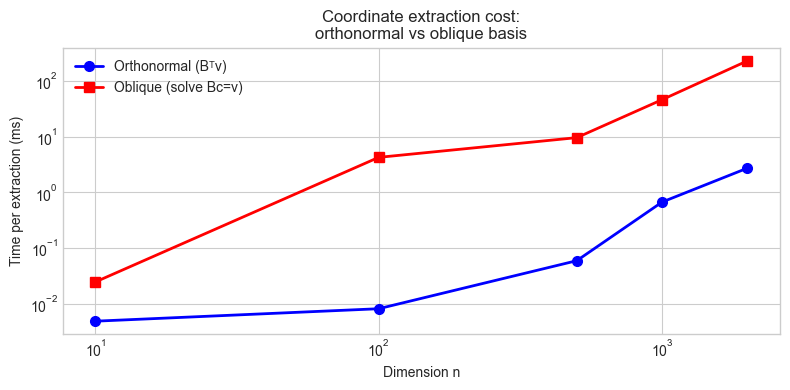

       n    ortho (ms)    oblique (ms)   speedup
      10        0.0049          0.0247       5.0x
     100        0.0082          4.2547     519.5x
     500        0.0596          9.6105     161.3x
    1000        0.6712         46.0874      68.7x
    2000        2.7254        229.2729      84.1x


In [4]:
# --- Experiment 2: Orthonormal vs oblique — computational cost ---
# Hypothesis: Orthonormal coordinate extraction is O(n) (dot products).
# General basis requires solving a linear system: O(n^2) or O(n^3).

import numpy as np
import time

DIMS = [10, 100, 500, 1000, 2000]  # <-- try larger values

times_ortho = []
times_oblique = []
N_REPS = 20

rng = np.random.default_rng(0)

for n in DIMS:
    # Orthonormal basis via QR
    A = rng.standard_normal((n, n))
    Q, _ = np.linalg.qr(A)
    v = rng.standard_normal(n)

    # Time orthonormal extraction
    start = time.perf_counter()
    for _ in range(N_REPS):
        c = Q.T @ v  # just a matrix-vector product
    times_ortho.append((time.perf_counter() - start) / N_REPS * 1000)

    # Oblique basis (random independent vectors)
    B = rng.standard_normal((n, n))
    start = time.perf_counter()
    for _ in range(N_REPS):
        c = np.linalg.solve(B, v)  # requires O(n^2) to O(n^3)
    times_oblique.append((time.perf_counter() - start) / N_REPS * 1000)

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(DIMS, times_ortho, 'bo-', lw=2, markersize=7, label='Orthonormal (Bᵀv)')
ax.loglog(DIMS, times_oblique, 'rs-', lw=2, markersize=7, label='Oblique (solve Bc=v)')
ax.set_xlabel('Dimension n')
ax.set_ylabel('Time per extraction (ms)')
ax.set_title('Coordinate extraction cost:\northonormal vs oblique basis')
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'n':>8}  {'ortho (ms)':>12}  {'oblique (ms)':>14}  {'speedup':>8}")
for n, to, tb in zip(DIMS, times_ortho, times_oblique):
    print(f"  {n:6d}  {to:12.4f}  {tb:14.4f}  {tb/to:8.1f}x")

---

## 7. Exercises

**Easy 1.** Vector **v** = (3, 4) in standard coordinates. Find its coordinates in the basis B = {(1, 1)/√2, (−1, 1)/√2}. Verify by reconstructing **v** from the computed coordinates.

**Easy 2.** If B is an orthonormal basis matrix (columns orthonormal), write a one-line expression for the coordinate vector of **v** in that basis. Why is this formula valid?

**Medium 1.** A robotics sensor gives position readings in a local frame with basis **b₁** = (cos30°, sin30°), **b₂** = (−sin30°, cos30°). The sensor reports a position of (2.0, 1.5) in its local frame. Find the position in world (standard) coordinates.

**Medium 2.** Two coordinate systems share the same origin. The first has basis {(1,0,0), (0,1,0), (0,0,1)} and the second has basis {(1,1,0)/√2, (−1,1,0)/√2, (0,0,1)}. Build the change-of-basis matrix from system 1 to system 2 and verify it is orthonormal (Rᵀ = R⁻¹).

**Hard.** Implement a 2D coordinate system visualizer: given any two linearly independent vectors as a basis, draw the resulting coordinate grid and allow the user to click a point on the plot and read off its coordinates in that basis. *(Use matplotlib's interactive mode or parametric line plotting.)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Multi-Frame Robot Position Tracker ---
#
# Problem: A robot has a body frame, a camera frame, and a world frame.
# All three are coordinate systems. Sensor data arrives in the camera frame;
# plans are made in the world frame. Build a transformation pipeline.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(0)

# --- Frame definitions ---
# World frame: standard (identity)
# Body frame: robot is at position (3, 2) in world, rotated 30° CCW
ROBOT_POS_WORLD = np.array([3.0, 2.0])
ROBOT_ANGLE_DEG = 30.0   # <-- try different angles
theta = np.radians(ROBOT_ANGLE_DEG)

# Body frame basis vectors (in world coordinates)
body_x = np.array([np.cos(theta), np.sin(theta)])   # robot's forward direction
body_y = np.array([-np.sin(theta), np.cos(theta)])  # robot's left direction
B_body = np.column_stack([body_x, body_y])

# Camera frame: mounted on robot, offset (0.5, 0) in body frame, rotated 15° CCW
CAM_OFFSET_BODY = np.array([0.5, 0.0])
CAM_ANGLE_DEG = 15.0     # <-- try different camera angles
phi = np.radians(CAM_ANGLE_DEG)
cam_x_body = np.array([np.cos(phi), np.sin(phi)])
cam_y_body = np.array([-np.sin(phi), np.cos(phi)])
B_cam_in_body = np.column_stack([cam_x_body, cam_y_body])

# --- Transformation pipeline ---
def camera_to_body(p_cam):
    """Convert camera-frame coordinates to body-frame coordinates."""
    return B_cam_in_body @ p_cam + CAM_OFFSET_BODY

def body_to_world(p_body):
    """Convert body-frame coordinates to world-frame coordinates."""
    return B_body @ p_body + ROBOT_POS_WORLD

def camera_to_world(p_cam):
    """Full pipeline: camera -> body -> world."""
    return body_to_world(camera_to_body(p_cam))

# --- Simulate obstacle detections in camera frame ---
obstacles_cam = [
    np.array([2.0, 0.3]),
    np.array([1.5, -0.5]),
    np.array([3.0, 0.0]),
]

print("Obstacle positions in different frames:")
print(f"{'Camera frame':>20}  {'Body frame':>20}  {'World frame':>20}")
obstacles_world = []
for obs_cam in obstacles_cam:
    obs_body = camera_to_body(obs_cam)
    obs_world = body_to_world(obs_body)
    obstacles_world.append(obs_world)
    print(f"  ({obs_cam[0]:5.2f},{obs_cam[1]:5.2f})    "
          f"  ({obs_body[0]:5.2f},{obs_body[1]:5.2f})    "
          f"  ({obs_world[0]:5.2f},{obs_world[1]:5.2f})")

# --- Visualization ---
fig, ax = plt.subplots(figsize=(8, 8))

# World frame grid
for i in np.arange(-1, 7):
    ax.axhline(i, color='lightblue', lw=0.7, alpha=0.5)
    ax.axvline(i, color='lightblue', lw=0.7, alpha=0.5)

# Robot body frame
ax.quiver(*ROBOT_POS_WORLD, *body_x, color='blue', scale=4,
          width=0.005, label='Robot body frame')
ax.quiver(*ROBOT_POS_WORLD, *body_y, color='blue', scale=4, width=0.005)

# Camera position in world
cam_pos_world = body_to_world(CAM_OFFSET_BODY)
cam_x_world = B_body @ cam_x_body
cam_y_world = B_body @ cam_y_body
ax.quiver(*cam_pos_world, *cam_x_world, color='green', scale=5,
          width=0.005, label='Camera frame')
ax.quiver(*cam_pos_world, *cam_y_world, color='green', scale=5, width=0.005)

# Robot and camera markers
ax.plot(*ROBOT_POS_WORLD, 'bs', markersize=12, zorder=5, label='Robot origin')
ax.plot(*cam_pos_world, 'g^', markersize=10, zorder=5, label='Camera')

# Obstacles in world frame
for i, (obs_cam, obs_world) in enumerate(zip(obstacles_cam, obstacles_world)):
    ax.plot(*obs_world, 'ro', markersize=10, zorder=5)
    ax.text(obs_world[0]+0.1, obs_world[1]+0.1,
            f'obs{i} cam=({obs_cam[0]:.1f},{obs_cam[1]:.1f})\n'
            f'world=({obs_world[0]:.2f},{obs_world[1]:.2f})',
            fontsize=8)

ax.set_xlim(-1, 7); ax.set_ylim(-1, 7)
ax.set_xlabel('World x'); ax.set_ylabel('World y')
ax.set_title(f'Robot at ({ROBOT_POS_WORLD[0]},{ROBOT_POS_WORLD[1]}), '
              f'rotated {ROBOT_ANGLE_DEG}°\nCamera offset, rotated {CAM_ANGLE_DEG}°')
ax.legend(loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What was covered:**
- A coordinate system = a basis. Coordinates are the unique representation of a vector in that basis.
- Orthonormal bases give the simplest coordinate extraction: cᵢ = **bᵢ** · **v** (dot product only).
- The change-of-basis matrix P converts coordinates from one system to another: [**v**]_B2 = P[**v**]_B1.
- Coordinate systems are fundamental to signal processing (Fourier), graphics (frame transforms), and ML (feature spaces).

**Backward connection:** This chapter applies ch139 (Basis) and ch141 (Independence) concretely: a coordinate system exists because a basis is independent (unique coordinates) and spans the space (every vector is reachable). *(Introduced in ch139, ch141.)*

**Forward connections:**
- In ch143 (Vector Transformations), we examine what happens to coordinate systems when a linear map is applied — transformations act on both the vectors and their coordinate representations.
- This will reappear in ch183 (Eigenvalue Computation): the eigenvector basis is the coordinate system in which a matrix acts as a pure scaling — the simplest possible representation.
- In ch186 (PCA), principal components define a new coordinate system that maximally decorrelates the data — coordinate change as a tool for insight.